In [1]:
from Loop import Train_model
from Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast
from Dataset import Boot_Segmentation_Dataset
from torchvision.transforms import ToPILImage
import yaml
from PIL import Image
import cv2
from Shadow_adder import cut_boot_from_photo
from torch.nn import functional as F
from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [2]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [3]:
dataset=Boot_Segmentation_Dataset(option['Segmentation']['img_path'],option['Segmentation']['label_path'],)
dataloader=DataLoader(dataset=dataset,batch_size=2,drop_last=False,shuffle=True)
assert dataset.all_items[0].split('/')[-1][:-4]==dataset.all_labels[0].split('/')[-1][:-4]

In [4]:
model=Unet(3,64).to(device)
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    model.load_state_dict(weights_dict)
    print('Найдены веса')
except:
    print('Весов нет, инициализируем новые')

loss_fn=BCELoss()
optimizer=AdamW(model.parameters(),lr=0.001)


Найдены веса


In [5]:
# def cut_boot_from_photo(img,mask,blur=False,shadow=False,shadow_img=False):
#     sig=nn.Sigmoid()

#     real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 

#     if blur:
#         real_mask=torch.tensor(blur_img(real_mask.float().numpy()))
#     new_img=real_mask.float()*img
#     non_mask = (sig(mask)<(sig(mask).max()+sig(mask).min())/2).float()
#     new_img+=non_mask
#     #ЕСЛИ ЧТО УБРАТЬ
#     print(real_mask)
#     real_mask=dilate(real_mask)
#     #ЕСЛИ ЧТО УБРАТЬ

#     if shadow:
#         non_mask_img=non_mask*img
#         non_mask_img[non_mask_img==0]=1

#         if shadow_img:
#             return (new_img-((non_mask_img.mean(axis=0)<0.9)*new_img)*0.3+0.3*((non_mask_img.mean(axis=0)<0.9)*img)).permute(1,2,0)
#         else:
#             return ((non_mask_img.mean(axis=0)<0.9)*img).permute(1,2,0)
    
#     return new_img #,non_boot_img

In [6]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
    new_img=real_mask.float()*img
    non_mask = (sig(mask)<(sig(mask).max()+sig(mask).min())/2).float()
    new_img+=non_mask    
    dilated_mask=dilate(real_mask,R=50)
    #dilated_non_mask=(dilated_mask<0.5).float()
    #dilated_non_mask_img=dilated_non_mask*img
    dilated_background=(dilated_mask<0.5).float()*img
    dilated_around_background=(dilated_mask.float()-real_mask.float())*img
    dilated_around_non_background=(dilated_mask.float()-real_mask.float())*new_img
    

    
    #Добавляем на новое фото тень
    #new_img_with_shadow=new_img-0.5*((dilated_around_background<0.9).float()*dilated_around_non_background)+0.5*((dilated_around_background<0.9).float()*dilated_around_background)


    mn_mx=0.9
    koef=0.3
    new_shadow=koef*((dilated_around_background<mn_mx).float()*dilated_around_background)
    new_img_with_shadow=new_img-koef*((dilated_around_background<mn_mx).float()*dilated_around_non_background)+koef*((dilated_around_background<mn_mx).float()*dilated_around_background)

    
    return new_img,real_mask,non_mask,dilated_mask,dilated_background,dilated_around_background,new_shadow,new_img_with_shadow

In [7]:
# def cut_boot_from_photo(img,mask):
#     sig=nn.Sigmoid()

#     real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
#     new_img=real_mask.float()*img
#     non_mask = (sig(mask)<(sig(mask).max()+sig(mask).min())/2).float()
#     return new_img,non_mask 

In [8]:
# for batch in dataloader:
#   bt=batch
#   break

# batch['img']=adjust_sharpness(adjust_contrast(batch['img'],2),2)
# pred=model(batch['img'].to(device))
# sig=nn.Sigmoid()
# a=cut_boot_from_photo(pred[0],batch['img'][0])

In [9]:
def dilate(mask,R=20):
    kernel_size=2*R +1
    dilitation_kernel=torch.ones(1,1,kernel_size,kernel_size)
    new_mask=F.conv2d(mask.float(),dilitation_kernel,padding=R)
    new_mask=new_mask>0
    return new_mask

In [10]:
def blur_img(img):
    blurred=cv2.GaussianBlur(img, ksize=(15, 15), sigmaX=5)
    return blurred

In [11]:
def evaluate_segm_model(model,batch,device=device):
    pred=model(adjust_sharpness(adjust_contrast(batch['img'],2),2).to(device))
    sig=nn.Sigmoid()

    
    for i in range(batch['img'].size(0)):

        #определяем наши переменные
        new_img,real_mask,non_mask,dilated_mask,dilated_background,dilated_around_background,new_shadow,new_img_with_shadow=cut_boot_from_photo(batch['img'][i],pred[i])

        
        fig=plt.figure(figsize=(30, 15)) 
    
        fig.add_subplot(1, 8, 1) 
        plt.imshow(batch['img'][i].permute(1,2,0).detach())
        plt.title('Фото') 
    
    
        fig.add_subplot(1, 8, 2) 
        plt.imshow(real_mask.permute(1,2,0).detach())
        plt.title('Маска') 

        fig.add_subplot(1, 8, 3) 
        plt.imshow(new_img.permute(1,2,0).detach())
        plt.title('Фото с белым фоном')

        fig.add_subplot(1, 8, 4) 
        plt.imshow(non_mask.permute(1,2,0).detach())
        plt.title('Расширенная маска')

        fig.add_subplot(1, 8, 5) 
        plt.imshow(new_shadow.permute(1,2,0).detach())
        plt.title('Фон маски')

        fig.add_subplot(1, 8, 6) 
        plt.imshow(new_img_with_shadow.permute(1,2,0).detach())
        plt.title('Новое фото')

In [12]:
sig=nn.Sigmoid()

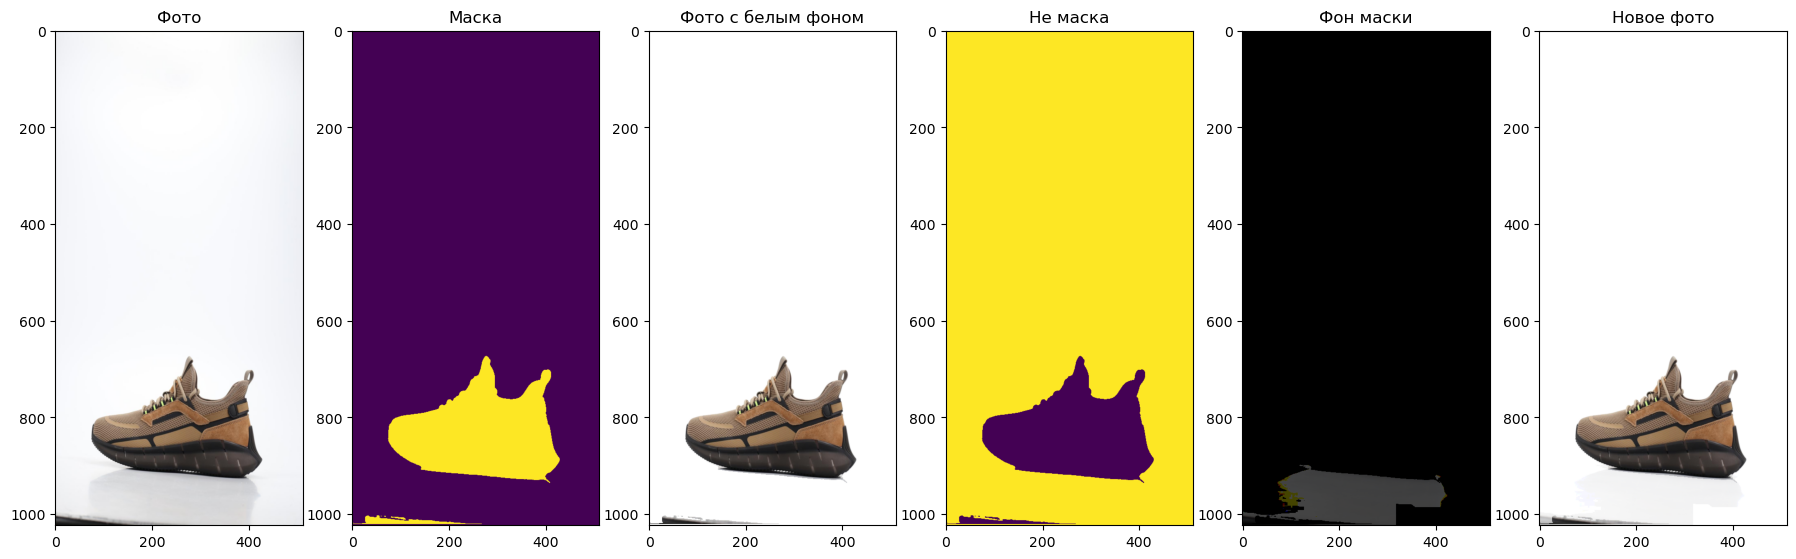

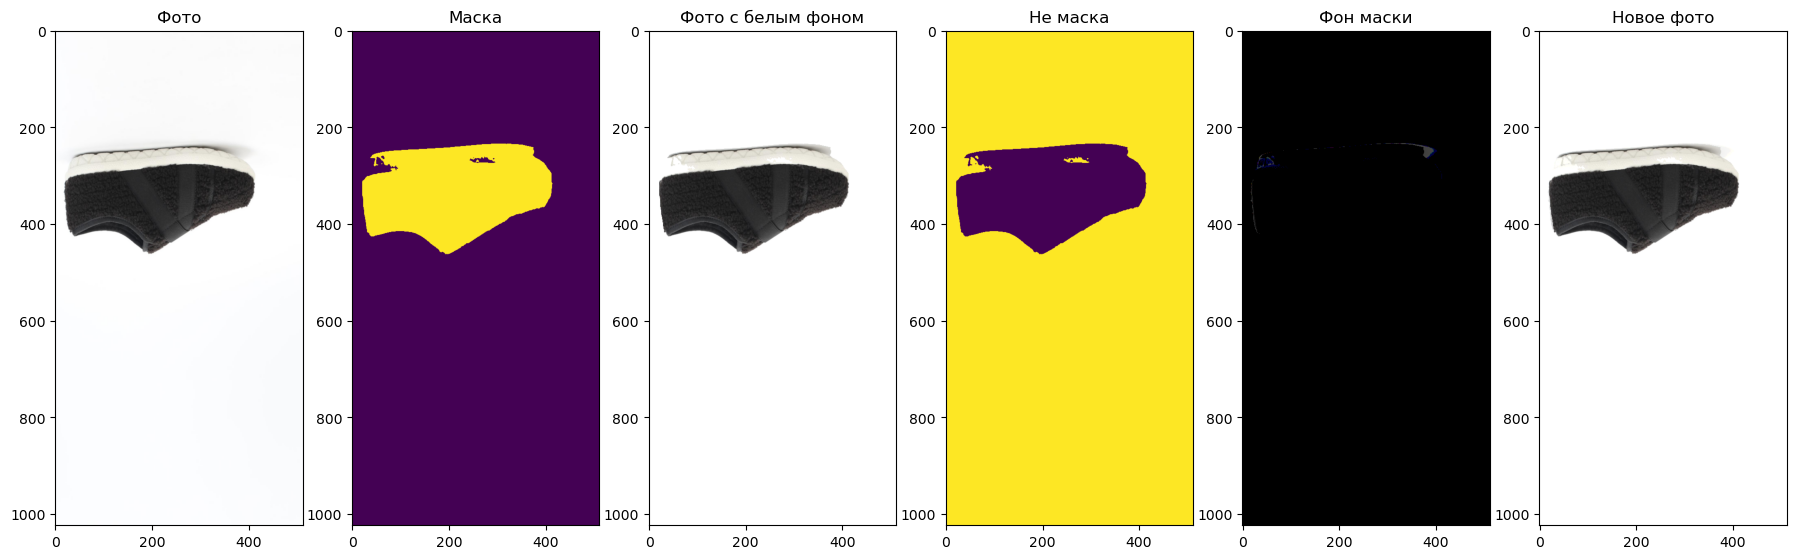

In [13]:
for batch in dataloader:
  bt=batch
  break
a=evaluate_segm_model(model=model,batch=bt)

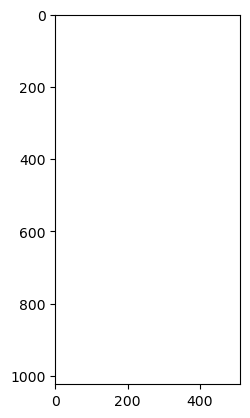

In [24]:
plt.imshow((a[1]!=1).float().permute(1,2,0))

# Тестируем на неразмеченном датасете

In [11]:
from torch.utils.data import Dataset
import os
from torchvision import transforms
class Boot_Segmentation_Dataset(Dataset):
    def __init__(self,img_path,label_path,transformation=None,back_transformation=None):
        super(Boot_Segmentation_Dataset,self).__init__()
        self.transformation=transformation
        self.back_transformation=back_transformation
        self.all_items=[os.path.join(img_path,img) for img in os.listdir(img_path)]
        self.all_labels=[os.path.join(label_path,label) for label in os.listdir(label_path)]
        self.all_items.sort()
        self.all_labels.sort()

        if self.transformation==None:
            self.transformation=transforms.Compose([
            transforms.Resize((1024,512)),
            transforms.ToTensor(),

            ])
        if self.back_transformation==None:
            self.back_transformation=transforms.Compose([
            transforms.Resize((512,1024)),
            transforms.ToTensor()
            ])
    def __len__(self):
        return len(self.all_items)
    def __getitem__(self,idx):
        img=Image.open(self.all_items[idx])
        label=Image.open(self.all_labels[idx])
        tensor_img=self.transformation(img)
        tensor_label=self.transformation(label)
        if img.size==(1824,1216):
          tensor_img=self.back_transformation(img).permute(0,2,1)
          tensor_label=self.back_transformation(label).permute(0,2,1)
        return {
            'img':tensor_img,
            'label':tensor_label
        }


eval_dataset=Boot_Segmentation_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots/',option['Segmentation']['label_path'],)
eval_dataloader=DataLoader(dataset=eval_dataset,batch_size=2,drop_last=False,shuffle=True)
#assert eval_dataset.all_items[0].split('/')[-1][:-4]==eval_dataset.all_labels[0].split('/')[-1][:-4]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8797092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8734375].


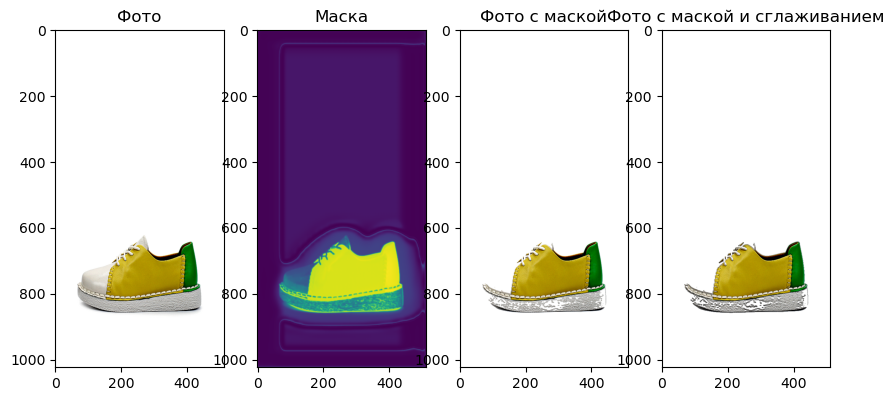

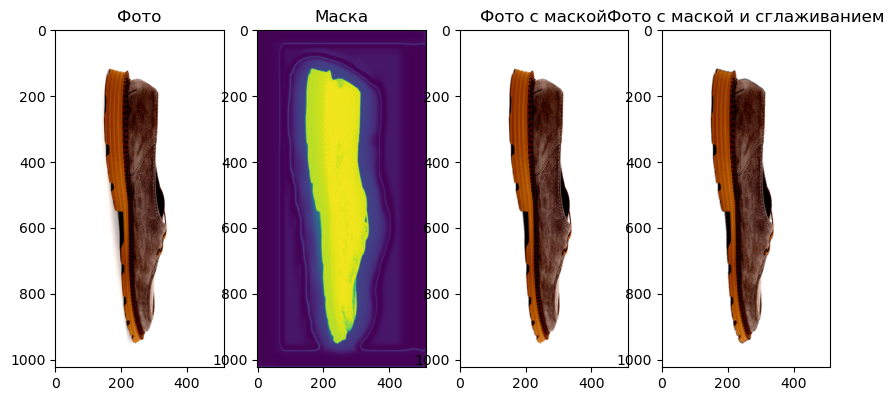

In [12]:
for batch in eval_dataloader:
  bt=batch
  break
evaluate_segm_model(model=model,batch=bt)

In [13]:
#странная темка с пикселями
N=20
kernel=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(2*N+1,2*N+1))
mask=model(bt['img'])

In [14]:
delated=cv2.dilate(mask[0].permute(1,2,0).detach().numpy(),kernel)
result=cv2.subtract(delated,mask[0].squeeze().detach().numpy())

In [15]:
bt['img'][0].shape

torch.Size([3, 1024, 512])

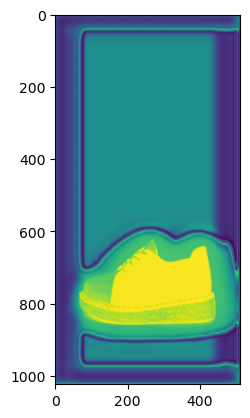

In [18]:
plt.imshow(mask[0].permute(1,2,0).detach())

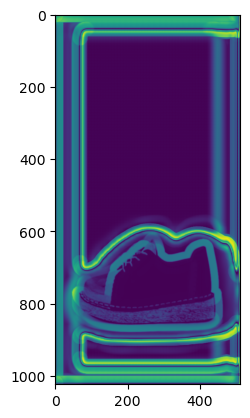

In [16]:
plt.imshow(result)

# Сохраняем предсказанные маски

In [23]:
def predict_masks(dataloader):
    trans=ToPILImage()
    cnt=0
    for batch in dataloader:
        pred_mask=model(batch['img'])
        for i in range((pred_mask).size(0)):
            pred_img=cut_boot_from_photo(batch['img'][i],pred_mask[i])
            pil_image=trans(pred_img)
            pil_image.save(f'{option['Result']['img_path']}/{cnt}',"JPEG")
            cnt+=1
            print(cnt)
    

In [ ]:
predict_masks(eval_dataloader)

2
1
2


In [12]:
b=np.array([True,True,False,True,False])
a=np.array([1,2,3,4,5])

In [18]:
np.invert(b)

array([False, False,  True, False,  True])

In [9]:
fig=plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

In [ ]:
fig.add_subplot(